In [1]:
import cv2
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import ale_py

In [6]:
env = gym.make("ALE/Freeway-v5", render_mode="human")
obs, info = env.reset()
for _ in range(100):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    env.render()

    if terminated or truncated:
        obs, info = env.reset()

env.close()

: 

In [2]:
def preprocess(obs):
    obs = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
    obs = cv2.resize(obs, (84, 84))
    obs = obs.flatten() / 255.0
    return obs

In [ ]:
class LinearSARSA:
    def __init__(self, state_size, action_size, alpha=0.01, gamma=0.90, epsilon=1, epsilon_min=0.1, epsilon_decay=0.995):
        self.action_size = action_size
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.weights = np.zeros((action_size, state_size))
        

    def get_q(self, state):
        return np.dot(self.weights, state)

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.action_size)
        q_values = self.get_q(state)
        return np.argmax(q_values)

    def update(self, state, action, reward, next_state, next_action, done):
        q_sa = np.dot(self.weights[action], state)
        q_s_next_a = np.dot(self.weights[next_action], next_state)
        td_error = reward + self.gamma * q_s_next_a - q_sa
        self.weights[action] += self.alpha * td_error * state

        if done:
            self.epsilon = max(self.epsilon * self.epsilon_decay, self.epsilon_min)


In [ ]:
env = gym.make("ALE/Breakout-v5", render_mode=None)

In [ ]:

agent = LinearSARSA(state_size=84*84, action_size=env.action_space.n)
reward_list = []
reward_episode = []
x_list = []
num_episodes = 1000
for episode in range(num_episodes):
    obs, info = env.reset()
    state = preprocess(obs)
    print(state)
    action = agent.choose_action(state)

    total_reward = 0
    x = 0
    done = False
    while not done:
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = preprocess(next_obs)
        next_action = agent.choose_action(next_state)

        agent.update(state, action, reward, next_state, next_action, done)

        state = next_state
        action = next_action
        total_reward += reward
        reward_list.append(reward)
        x += 1
    x_list.append(x)
    reward_episode.append(total_reward)

    print(f"Episode {episode+1}: Total Reward = {total_reward}, Epsilon = {agent.epsilon:.3f}")

env.close()


[0. 0. 0. ... 0. 0. 0.]
Episode 1: Total Reward = 1.0, Epsilon = 0.995
[0. 0. 0. ... 0. 0. 0.]
Episode 2: Total Reward = 2.0, Epsilon = 0.990
[0. 0. 0. ... 0. 0. 0.]
Episode 3: Total Reward = 0.0, Epsilon = 0.985
[0. 0. 0. ... 0. 0. 0.]
Episode 4: Total Reward = 2.0, Epsilon = 0.980
[0. 0. 0. ... 0. 0. 0.]
Episode 5: Total Reward = 2.0, Epsilon = 0.975
[0. 0. 0. ... 0. 0. 0.]


C:\Users\crist\AppData\Local\Temp\ipykernel_27384\3099141587.py:25: RuntimeWarning: invalid value encountered in multiply
  self.weights[action] += self.alpha * td_error * state
C:\Users\crist\AppData\Local\Temp\ipykernel_27384\3099141587.py:24: RuntimeWarning: invalid value encountered in scalar subtract
  td_error = reward + self.gamma * q_s_next_a - q_sa


Episode 6: Total Reward = 2.0, Epsilon = 0.970
[0. 0. 0. ... 0. 0. 0.]
Episode 7: Total Reward = 2.0, Epsilon = 0.966
[0. 0. 0. ... 0. 0. 0.]
Episode 8: Total Reward = 0.0, Epsilon = 0.961
[0. 0. 0. ... 0. 0. 0.]
Episode 9: Total Reward = 2.0, Epsilon = 0.956
[0. 0. 0. ... 0. 0. 0.]
Episode 10: Total Reward = 2.0, Epsilon = 0.951
[0. 0. 0. ... 0. 0. 0.]
Episode 11: Total Reward = 2.0, Epsilon = 0.946
[0. 0. 0. ... 0. 0. 0.]
Episode 12: Total Reward = 1.0, Epsilon = 0.942
[0. 0. 0. ... 0. 0. 0.]
Episode 13: Total Reward = 0.0, Epsilon = 0.937
[0. 0. 0. ... 0. 0. 0.]
Episode 14: Total Reward = 2.0, Epsilon = 0.932
[0. 0. 0. ... 0. 0. 0.]
Episode 15: Total Reward = 3.0, Epsilon = 0.928
[0. 0. 0. ... 0. 0. 0.]
Episode 16: Total Reward = 2.0, Epsilon = 0.923
[0. 0. 0. ... 0. 0. 0.]
Episode 17: Total Reward = 0.0, Epsilon = 0.918
[0. 0. 0. ... 0. 0. 0.]
Episode 18: Total Reward = 3.0, Epsilon = 0.914
[0. 0. 0. ... 0. 0. 0.]
Episode 19: Total Reward = 3.0, Epsilon = 0.909
[0. 0. 0. ... 0. 0. 

C:\Users\crist\AppData\Local\Temp\ipykernel_27384\1976390518.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


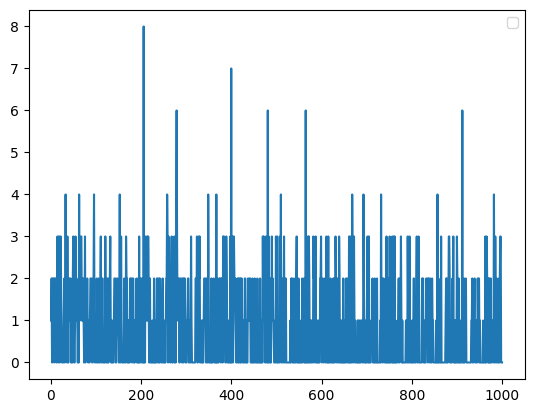

In [26]:
episodes = np.arange(1, num_episodes + 1)
plt.plot(episodes, reward_episode)
plt.legend()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import random
import numpy as np

In [5]:
class DeepQNetwork(nn.Module):
    def __init__(self, input_channels, num_actions):
        super(DeepQNetwork, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        self.fc1 = nn.Linear(7 * 7 * 64, 512)
        self.fc2 = nn.Linear(512, num_actions)

    def forward(self, x):
        x = F.relu(self.conv1(x))   # [batch, 32, 20, 20]
        x = F.relu(self.conv2(x))   # [batch, 64, 9, 9]
        x = F.relu(self.conv3(x))   # [batch, 64, 7, 7]
        x = x.view(x.size(0), -1)   # Flatten
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [6]:
num_actions = env.action_space.n
model = DeepQNetwork(input_channels=4, num_actions=num_actions)  # We'll stack 4 frames

dummy_input = torch.zeros((1, 4, 84, 84))  # batch_size=1, 4 stacked frames
output = model(dummy_input)

print("Output Q-values shape:", output.shape)  # should be [1, num_actions]


Output Q-values shape: torch.Size([1, 4])


In [ ]:
def preprocess_frame(frame):
    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    # Resize to 84x84
    resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)
    # Normalize to [0, 1]
    normalized = resized / 255.0
    return normalized.astype(np.float32)


In [ ]:
from collections import deque

class FrameStack:
    def __init__(self, stack_size=4):
        self.stack_size = stack_size
        self.frames = deque(maxlen=stack_size)

    def reset(self, frame):
        processed = preprocess_frame(frame)
        self.frames = deque([processed] * self.stack_size, maxlen=self.stack_size)
        return np.stack(self.frames, axis=0)

    def append(self, frame):
        processed = preprocess_frame(frame)
        self.frames.append(processed)
        return np.stack(self.frames, axis=0)


In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.pos = 0

    def push(self, state, action, reward, next_state, next_action, done):
        data = (state, action, reward, next_state, next_action, done)
        if len(self.buffer) < self.capacity:
            self.buffer.append(data)
        else:
            self.buffer[self.pos] = data
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, next_actions, dones = map(np.array, zip(*batch))

        return (
            torch.tensor(states, dtype=torch.float32),
            torch.tensor(actions, dtype=torch.int64),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(next_states, dtype=torch.float32),
            torch.tensor(next_actions, dtype=torch.int64),
            torch.tensor(dones, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buffer)


In [10]:
def epsilon_greedy(model, state, epsilon, device):
    if random.random() < epsilon:
        return env.action_space.sample()
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_vals = model(state_tensor)
    return q_vals.argmax().item()


In [12]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random

# Hyperparameters
num_episodes   = 1000
batch_size     = 32
gamma          = 0.99
epsilon_start  = 1.0
epsilon_end    = 0.1
epsilon_decay  = 1e-5
alpha          = 1e-4
replay_capacity= 100000

# Initialize modules
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net = DeepQNetwork(input_channels=4, num_actions=env.action_space.n).to(device)
optimizer  = optim.Adam(policy_net.parameters(), lr=alpha)
buffer     = ReplayBuffer(replay_capacity)
frame_stack = FrameStack()

total_reward_list = []

epsilon = epsilon_start

for episode in range(1, num_episodes+1):
    obs, _ = env.reset()
    state = frame_stack.reset(obs)
    action = epsilon_greedy(policy_net, state, epsilon, device)

    total_reward = 0
    done = False

    while not done:
        # Step in env
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        next_state = frame_stack.append(obs)
        next_action = epsilon_greedy(policy_net, next_state, epsilon, device)

        # Store transition
        buffer.push(state, action, reward, next_state, next_action, done)

        state, action = next_state, next_action

        # Decrease epsilon
        epsilon = max(epsilon_end, epsilon - epsilon_decay)

        # Update policy if enough samples
        if len(buffer) >= batch_size:
            states, actions, rewards, next_states, next_actions, dones = buffer.sample(batch_size)

            # Move to device
            states      = states.to(device)           # shape: [B,4,84,84]
            actions     = actions.to(device)          # [B]
            rewards     = rewards.to(device)          # [B]
            next_states = next_states.to(device)      # [B,4,84,84]
            next_actions= next_actions.to(device)     # [B]
            dones       = dones.to(device)            # [B]

            # Compute current Q(s,a)
            q_values = policy_net(states)             # [B, num_actions]
            q_sa     = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)  # [B]

            # Compute Q(s',a')
            q_next = policy_net(next_states)          # [B, num_actions]
            q_snext_anext = q_next.gather(1, next_actions.unsqueeze(1)).squeeze(1)  # [B]

            # SARSA TD-target
            td_target = rewards + gamma * q_snext_anext * (1 - dones)

            # Loss = MSE between q_sa and td_target (semi-gradient update)
            loss = F.mse_loss(q_sa, td_target.detach())

            # Optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    print(f"Episode {episode} — Total Reward: {total_reward:.2f} — Epsilon: {epsilon:.3f}")
    total_reward_list.append(total_reward)
env.close()


Episode 1 — Total Reward: 1.00 — Epsilon: 0.998
Episode 2 — Total Reward: 4.00 — Epsilon: 0.995
Episode 3 — Total Reward: 1.00 — Epsilon: 0.994
Episode 4 — Total Reward: 0.00 — Epsilon: 0.992
Episode 5 — Total Reward: 0.00 — Epsilon: 0.991
Episode 6 — Total Reward: 0.00 — Epsilon: 0.989
Episode 7 — Total Reward: 2.00 — Epsilon: 0.987
Episode 8 — Total Reward: 0.00 — Epsilon: 0.986
Episode 9 — Total Reward: 1.00 — Epsilon: 0.984
Episode 10 — Total Reward: 3.00 — Epsilon: 0.982
Episode 11 — Total Reward: 1.00 — Epsilon: 0.980
Episode 12 — Total Reward: 0.00 — Epsilon: 0.979
Episode 13 — Total Reward: 0.00 — Epsilon: 0.977
Episode 14 — Total Reward: 0.00 — Epsilon: 0.976
Episode 15 — Total Reward: 0.00 — Epsilon: 0.974
Episode 16 — Total Reward: 2.00 — Epsilon: 0.972
Episode 17 — Total Reward: 1.00 — Epsilon: 0.970
Episode 18 — Total Reward: 2.00 — Epsilon: 0.968
Episode 19 — Total Reward: 3.00 — Epsilon: 0.966
Episode 20 — Total Reward: 3.00 — Epsilon: 0.963
Episode 21 — Total Reward: 0.

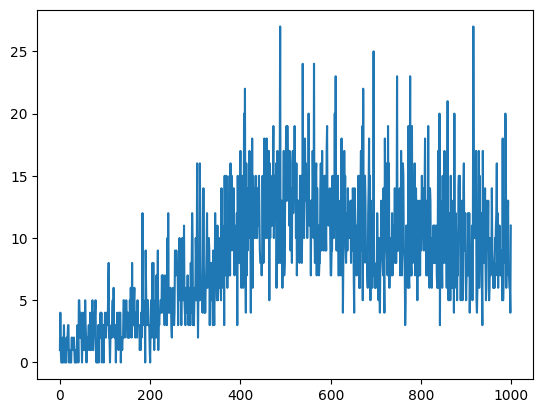

In [13]:
plt.plot(total_reward_list)